In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

import kagglehub
kagglehub.competition_download('playground-series-s6e7')
BASE = '/kaggle/input/competitions/playground-series-s6e7'
print('Setup ✓')

Setup ✓


In [8]:
train = pd.read_csv(f'{BASE}/train.csv')
test  = pd.read_csv(f'{BASE}/test.csv')

In [9]:
train.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [10]:
train.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [11]:
train.dtypes

id                           int64
health_condition            object
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                   object
stress_level                object
sleep_quality               object
physical_activity_level     object
smoking_alcohol             object
gender                      object
dtype: object

In [14]:
train['health_condition'].value_counts()

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

health_condition,at-risk,fit,unhealthy
sleep_duration,0.110213,0.109439,0.109746
heart_rate,0.011511,0.010879,0.010030
bmi,0.020845,0.028616,0.007051
calorie_expenditure,0.076532,0.077004,0.076883
step_count,0.020246,0.019923,0.019507
exercise_duration,0.009910,0.010477,0.010602
water_intake,0.062740,0.063412,0.065415
diet_type,0.010104,0.008818,0.009753
stress_level,0.120038,0.119564,0.119915
sleep_quality,0.084621,0.085270,0.083050


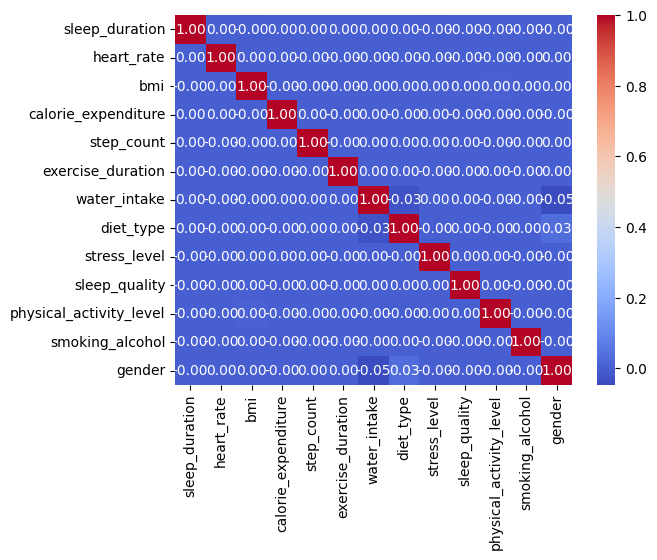

In [15]:
# co-missingness: stessi 6901 casi?
(train['exercise_duration'].isnull() & train['diet_type'].isnull()).sum()

# matrice di correlazione della missingness
msno = train.drop(columns=['id', 'health_condition']).isnull()
sns.heatmap(msno.corr(), annot=True, fmt='.2f', cmap='coolwarm')

# la domanda da un milione di punti: i null correlano col target?
train.groupby('health_condition')[msno.columns].apply(lambda g: g.isnull().mean()).T